In [50]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import yfinance as yf
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats

In [51]:
tickers = ['^BVSP', 'BRL=X', '^VIX', 'CL=F', 'GC=F'] # ibov, cambio, vix, petroleo, ouro
start_date = '2010-01-01' 
end_date =  '2025-01-01'
print(start_date, end_date)

def pegarCotacoes(tickers, start_date, end_date):
    df = yf.download(tickers, start_date, end_date, auto_adjust=False)
    df = df['Adj Close']
    return df

df_cotacoes = pegarCotacoes(tickers, start_date, end_date)
df_cotacoes = df_cotacoes.ffill()
df_cotacoes = df_cotacoes.ffill().dropna()
display(df_cotacoes)

[*******************   40%                       ]  2 of 5 completed

2010-01-01 2025-01-01


[*********************100%***********************]  5 of 5 completed


Ticker,BRL=X,CL=F,GC=F,^BVSP,^VIX
Date,,,,,
2010-01-04,1.7190,81.510002,1117.699951,70045.0,20.040001
2010-01-05,1.7370,81.769997,1118.099976,70240.0,19.350000
2010-01-06,1.7315,83.180000,1135.900024,70729.0,19.160000
2010-01-07,1.7389,82.660004,1133.099976,70451.0,19.059999
2010-01-08,1.7320,82.750000,1138.199951,70263.0,18.129999
...,...,...,...,...,...
2024-12-25,6.1756,70.099998,2620.000000,120767.0,14.270000
2024-12-26,6.1828,69.620003,2638.800049,121078.0,14.730000
2024-12-27,6.1485,70.599998,2617.199951,120269.0,15.950000


In [52]:
# retorno de logs diarios
df_returns = np.log(df_cotacoes/df_cotacoes.shift(1)).dropna()
df_returns.columns = ['CAMBIO', 'PETROLEO', 'OURO', 'IBOV','VIX']

# features
df_features = pd.DataFrame(index= df_returns.index)

# retorno IBOV 
df_features['ret_ibov'] = df_returns['IBOV']

# volatilidade realizada (janela 21 dias)
df_features['vol_21'] = df_returns['IBOV'].rolling(21).std() * np.sqrt(252)

# zscore do retorno (janela 63 dias)
rolling_mean = df_returns['IBOV'].rolling(63).mean()
rolling_std = df_returns['IBOV'].rolling(63).std()
df_features['zscore_63'] = (df_returns['IBOV'] - rolling_mean) / rolling_std 

# variaveis macro
df_features['ret_cambio'] = df_returns['CAMBIO']
df_features['ret_vix'] = df_returns['VIX']
df_features['ret_petroleo'] = df_returns['PETROLEO']
df_features['ret_ouro'] = df_returns['OURO']

# momentum (retorno acumulado 21 dias)
df_features['mom_21'] = df_returns['IBOV'].rolling(21).sum()

df_features.dropna(inplace=True)

print(df_features.shape)
print(df_features.describe().round(4))

(3847, 8)
        ret_ibov     vol_21  zscore_63  ret_cambio    ret_vix  ret_petroleo  \
count  3847.0000  3847.0000  3847.0000   3847.0000  3847.0000     3847.0000   
mean      0.0001     0.2074    -0.0193      0.0003    -0.0000        0.0001   
std       0.0146     0.1022     1.0117      0.0107     0.0766        0.0254   
min      -0.1599     0.0666    -5.5667     -0.0638    -0.3506       -0.2822   
25%      -0.0073     0.1538    -0.6176     -0.0053    -0.0414       -0.0109   
50%       0.0000     0.1890    -0.0092      0.0001    -0.0035        0.0001   
75%       0.0080     0.2366     0.6097      0.0059     0.0329        0.0119   
max       0.1302     1.2930     3.6457      0.0725     0.7682        0.3196   

        ret_ouro     mom_21  
count  3847.0000  3847.0000  
mean      0.0002     0.0032  
std       0.0099     0.0660  
min      -0.0982    -0.5813  
25%      -0.0043    -0.0329  
50%       0.0001     0.0039  
75%       0.0053     0.0444  
max       0.0578     0.2331  


In [53]:

from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

# ret_ibov como série principal
modelos_msar = MarkovAutoregression(df_features['ret_ibov'], k_regimes=3, order=1, switching_ar=True, switching_variance=True)
resultado = modelos_msar.fit(search_reps=20, search_scale=True, disp=False)

print(resultado.summary())

                         Markov Switching Model Results                         
Dep. Variable:                 ret_ibov   No. Observations:                 3846
Model:             MarkovAutoregression   Log Likelihood               16082.750
Date:                  Wed, 22 Jul 2026   AIC                         -32135.500
Time:                          17:22:25   BIC                         -32041.679
Sample:                               0   HQIC                        -32102.177
                                 - 3846                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0031   2.62e-11  -1.19e+08      0.000      -0.003      -0.003
sigma2         0.0026   2.62e-11   9

In [54]:
probs = pd.DataFrame(
    resultado.smoothed_marginal_probabilities.iloc[:, :3].values,
    index=resultado.smoothed_marginal_probabilities.index,
    columns=['P_Lateral', 'P_Crise', 'P_Bull']
)
probs['regime'] = probs[['P_Lateral', 'P_Crise', 'P_Bull']].values.argmax(axis=1)
df_signal = df_features.loc[probs.index].copy()
df_signal['regime'] = probs['regime'].values

df_signal['signal'] = 0

bull_mask = df_signal['regime'] == 2
lat_mask  = df_signal['regime'] == 0

df_signal.loc[bull_mask & (df_signal['mom_21'] > 0), 'signal'] =  1
df_signal.loc[bull_mask & (df_signal['mom_21'] <= 0), 'signal'] = 0

df_signal.loc[lat_mask & (df_signal['zscore_63'] < -2.0), 'signal'] =  1
df_signal.loc[lat_mask & (df_signal['zscore_63'] >  2.0), 'signal'] = -1

df_signal.loc[df_signal['regime'] == 1, 'signal'] = 0

print(f"\nSinais gerados")
print(f"Sinais:\n{df_signal['signal'].value_counts()}")
print(f"\nRegimes:\n{df_signal['regime'].value_counts()}")


Sinais gerados
Sinais:
signal
 0    3726
 1     112
-1       8
Name: count, dtype: int64

Regimes:
regime
1    3578
2     195
0      73
Name: count, dtype: int64



  Estratégia MS-AR v2
  Retorno anual  : 0.01%
  Volatilidade   : 3.73%
  Sharpe Ratio   : 0.00
  Max Drawdown   : -10.26%
  Calmar Ratio   : 0.00

  Buy & Hold IBOV
  Retorno anual  : 3.44%
  Volatilidade   : 23.13%
  Sharpe Ratio   : 0.15
  Max Drawdown   : -55.16%
  Calmar Ratio   : 0.06


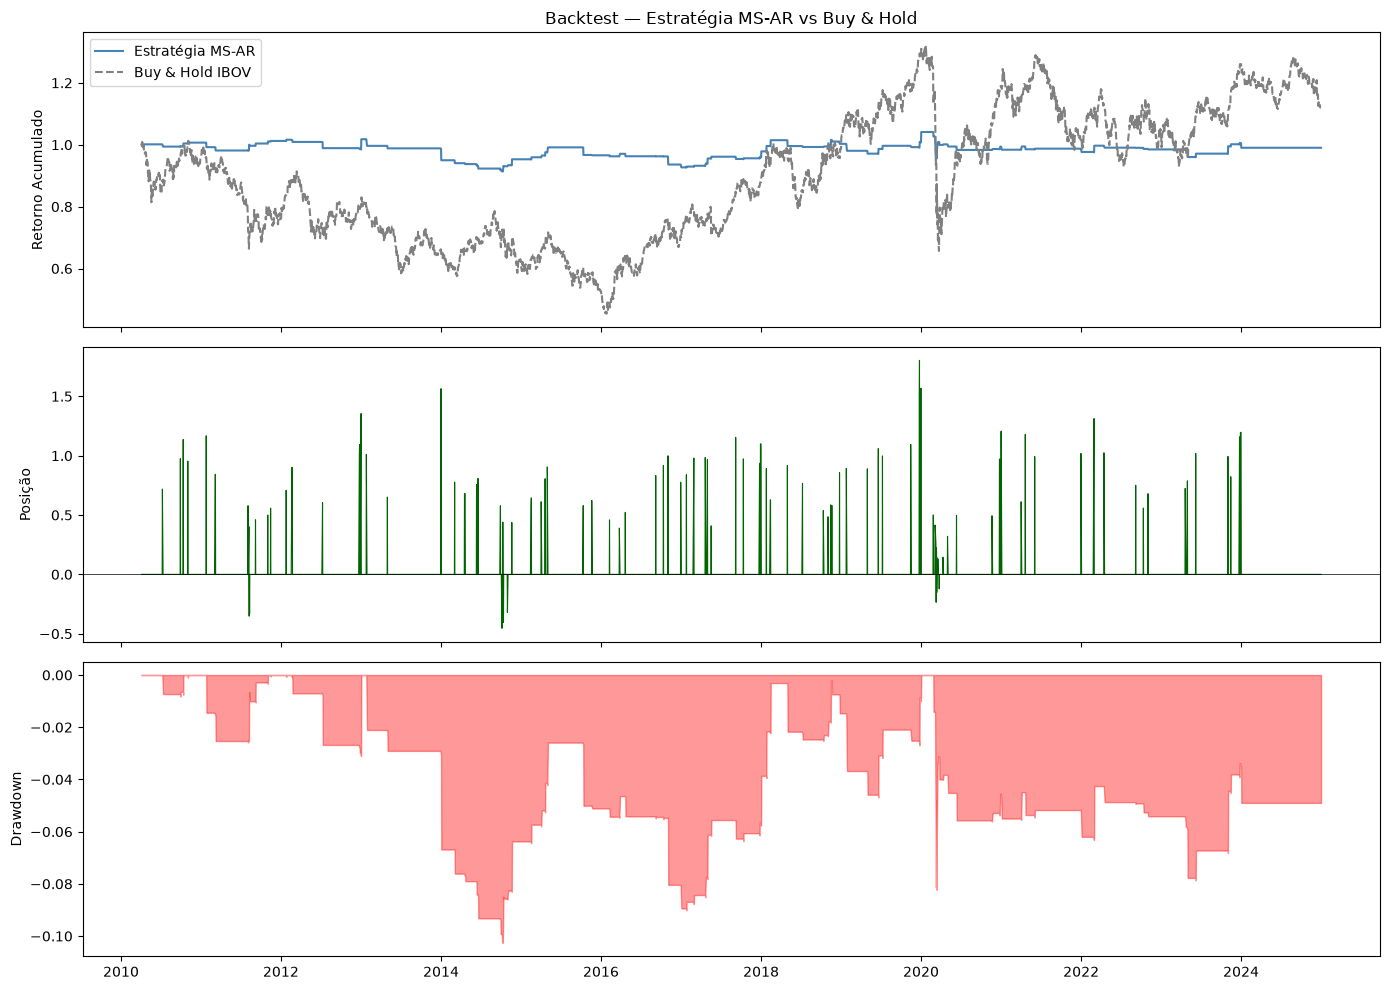

In [55]:
# ── 6. VOLATILITY TARGETING (sizing) ─────────────────────────────────────────
VOL_TARGET = 0.15          # 15% a.a. — alvo de volatilidade
COST       = 0.001         # 0.1% por lado (custo de transação)
VOL_FLOOR  = 0.05          # evita alavancagem excessiva em vol muito baixa

df_signal['vol_target'] = (VOL_TARGET / df_signal['vol_21'].clip(lower=VOL_FLOOR)).clip(upper=2.0)
df_signal['position']   = df_signal['signal'] * df_signal['vol_target']

df_bt = df_signal.copy()
df_bt['ret_estrategia'] = df_bt['position'].shift(1) * df_bt['ret_ibov']
df_bt['turnover']       = df_bt['position'].diff().abs()
df_bt['custo']          = df_bt['turnover'] * COST
df_bt['ret_liquido']    = df_bt['ret_estrategia'] - df_bt['custo']
df_bt['ret_bh']         = df_bt['ret_ibov']
df_bt.dropna(inplace=True)

# ── 8. MÉTRICAS ───────────────────────────────────────────────────────────────
def metricas(serie, nome):
    ret_anual  = serie.mean() * 252
    vol_anual  = serie.std() * np.sqrt(252)
    sharpe     = ret_anual / vol_anual
    cum        = (1 + serie).cumprod()
    drawdown   = (cum / cum.cummax() - 1)
    max_dd     = drawdown.min()
    calmar     = ret_anual / abs(max_dd)
    print(f"\n{'='*40}")
    print(f"  {nome}")
    print(f"{'='*40}")
    print(f"  Retorno anual  : {ret_anual:.2%}")
    print(f"  Volatilidade   : {vol_anual:.2%}")
    print(f"  Sharpe Ratio   : {sharpe:.2f}")
    print(f"  Max Drawdown   : {max_dd:.2%}")
    print(f"  Calmar Ratio   : {calmar:.2f}")
    return cum

cum_estrategia = metricas(df_bt['ret_liquido'], 'Estratégia MS-AR v2')
cum_bh = metricas(df_bt['ret_bh'], 'Buy & Hold IBOV')

# ── 9. VISUALIZAÇÃO ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(cum_estrategia.index, cum_estrategia, label='Estratégia MS-AR', color='steelblue')
axes[0].plot(cum_bh.index, cum_bh, label='Buy & Hold IBOV', color='gray', linestyle='--')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].legend()
axes[0].set_title('Backtest — Estratégia MS-AR vs Buy & Hold')

axes[1].plot(df_bt.index, df_bt['position'], color='darkgreen', linewidth=0.8)
axes[1].set_ylabel('Posição')
axes[1].axhline(0, color='black', linewidth=0.5)

dd = (cum_estrategia / cum_estrategia.cummax() - 1)
axes[2].fill_between(dd.index, dd, color='red', alpha=0.4)
axes[2].set_ylabel('Drawdown')

plt.tight_layout()
plt.show()